In [1]:
import torch
import pytorch_forecasting
import lightning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('torch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))
print('pytorch-forecasting:', pytorch_forecasting.__version__)
print('lightning:', lightning.__version__)

/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/pytorch_forecasting/models/base_model.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


torch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 5060 Ti
pytorch-forecasting: 1.1.1
lightning: 2.6.1


In [2]:
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import QuantileLoss
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping

print("Imports OK")

Imports OK


In [3]:
from lightning.pytorch.callbacks import EarlyStopping
import lightning.pytorch as pl

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer = pl.Trainer(
    max_epochs=50,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
)

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluído.")

Treino: 8 batches | Validação: 1 batches


In [5]:
tft = TemporalFusionTransformer.from_dataset(
    treino,
    learning_rate=0.03,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    optimizer='adam',
    log_interval=10,
    reduce_on_plateau_patience=4,
)

print(f"Parâmetros: {tft.size()/1e3:.1f}k")

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer = pl.Trainer(
    max_epochs=50,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
)

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluído.")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Parâmetros: 66.6k


TypeError: `model` must be a `LightningModule` or `torch._dynamo.OptimizedModule`, got `TemporalFusionTransformer`

In [6]:
import lightning.pytorch as pl
print(pl.__file__)

import pytorch_lightning
print(pytorch_lightning.__file__)

/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/__init__.py
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/pytorch_lightning/__init__.py


In [7]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer = pl.Trainer(
    max_epochs=50,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
)

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluído.")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


TypeError: `model` must be a `LightningModule` or `torch._dynamo.OptimizedModule`, got `TemporalFusionTransformer`

In [8]:
print(type(tft).__mro__)


(<class 'pytorch_forecasting.models.temporal_fusion_transformer.TemporalFusionTransformer'>, <class 'pytorch_forecasting.models.base_model.BaseModelWithCovariates'>, <class 'pytorch_forecasting.models.base_model.BaseModel'>, <class 'pytorch_forecasting.utils._utils.InitialParameterRepresenterMixIn'>, <class 'lightning.pytorch.core.module.LightningModule'>, <class 'lightning.fabric.utilities.device_dtype_mixin._DeviceDtypeModuleMixin'>, <class 'lightning.pytorch.core.mixins.hparams_mixin.HyperparametersMixin'>, <class 'lightning.pytorch.core.hooks.ModelHooks'>, <class 'lightning.pytorch.core.hooks.DataHooks'>, <class 'lightning.pytorch.core.hooks.CheckpointHooks'>, <class 'torch.nn.modules.module.Module'>, <class 'pytorch_forecasting.utils._utils.TupleOutputMixIn'>, <class 'object'>)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoi

Sanity Checking DataLoader 0:   0%|                                                               | 0/1 [00:00<?, ?it/s]

/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


AttributeError: 'ExperimentWriter' object has no attribute 'add_figure'

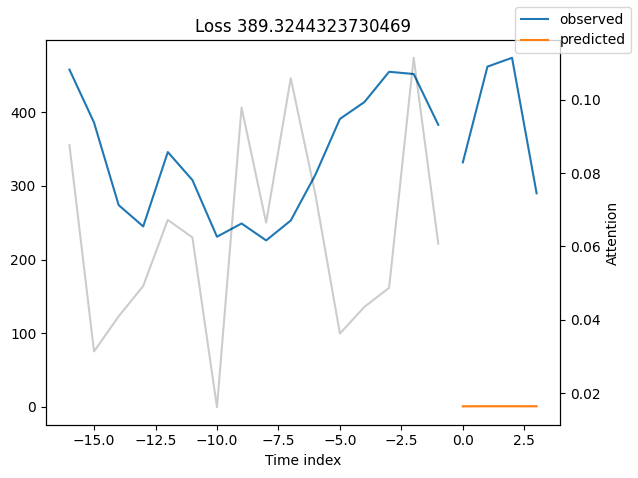

In [9]:
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer = Trainer(
    max_epochs=50,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
)

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluído.")

In [10]:
torch.set_float32_matmul_precision('medium')

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer = Trainer(
    max_epochs=50,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
    logger=False,
)

# Desabilitar log de figuras
tft.log_interval = -1

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluído.")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


AttributeError: property 'log_interval' of 'TemporalFusionTransformer' object has no setter

In [11]:
torch.set_float32_matmul_precision('medium')

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping

# Recriar o modelo com log_interval=-1
tft = TemporalFusionTransformer.from_dataset(
    treino,
    learning_rate=0.03,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    optimizer='adam',
    log_interval=-1,
    reduce_on_plateau_patience=4,
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer = Trainer(
    max_epochs=50,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
    logger=False,
)

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluído.")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   

/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 0: 100%|███████████████████████████████████████████████████| 8/8 [00:00<00:00, 19.96it/s, train_loss_step=1.52e+3]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|███████████| 8/8 [00:00<00:00, 31.49it/s, train_loss_step=912.0, val_loss=379.0, train_loss_epoch=1.14e+3]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|████████████| 8/8 [00:00<00:00, 31.52it/s, train_loss_step=831.0, val_loss=362.0, train_loss_epoch=1.1e+3]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                   

In [12]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Previsões no conjunto de teste
predictions = tft.predict(val_loader, return_y=True)

# Extrair valores reais e previstos (mediana - quantil 0.5)
y_real = predictions.y[0].numpy()
y_pred = predictions.output.numpy()[:, :, 3]  # quantil 0.5 (mediana)

# MAE por semana
for s in range(4):
    mae = mean_absolute_error(y_real[:, s], y_pred[:, s])
    print(f"Semana +{s+1} — MAE: {mae:.1f} casos")

print(f"\nMédia real no teste: {y_real.mean():.1f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [13]:
y_real = predictions.y[0].cpu().numpy()
y_pred = predictions.output.cpu().numpy()[:, :, 3]

for s in range(4):
    mae = mean_absolute_error(y_real[:, s], y_pred[:, s])
    print(f"Semana +{s+1} — MAE: {mae:.1f} casos")

print(f"\nMédia real no teste: {y_real.mean():.1f}")

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [14]:
print("y_real shape:", predictions.y[0].cpu().numpy().shape)
print("y_pred shape:", predictions.output.cpu().numpy().shape)


y_real shape: (1, 4)
y_pred shape: (1, 4)


In [15]:
y_real = predictions.y[0].cpu().numpy()
y_pred = predictions.output.cpu().numpy()

print("y_real:", y_real)
print("y_pred:", y_pred)

for s in range(4):
    mae = mean_absolute_error(y_real[:, s], y_pred[:, s])
    print(f"Semana +{s+1} — MAE: {mae:.1f} casos")

print(f"\nMédia real no teste: {y_real.mean():.1f}")


y_real: [[332. 462. 474. 290.]]
y_pred: [[782.6766  782.7093  782.68146 782.7612 ]]
Semana +1 — MAE: 450.7 casos
Semana +2 — MAE: 320.7 casos
Semana +3 — MAE: 308.7 casos
Semana +4 — MAE: 492.8 casos

Média real no teste: 389.5


In [16]:
# Reduzir split para ter mais amostras de validação
SPLIT = int(len(df_tft) * 0.7)

treino = TimeSeriesDataSet(
    df_tft[df_tft['time_idx'] <= SPLIT],
    time_idx='time_idx',
    target='casos',
    group_ids=['grupo'],
    min_encoder_length=JANELA,
    max_encoder_length=JANELA,
    min_prediction_length=HORIZONTE,
    max_prediction_length=HORIZONTE,
    time_varying_known_categoricals=['semana', 'mes'],
    time_varying_unknown_reals=['casos'],
    target_normalizer=None,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validacao = TimeSeriesDataSet.from_dataset(
    treino, df_tft, predict=True, stop_randomization=True
)

train_loader = treino.to_dataloader(train=True, batch_size=32, num_workers=0)
val_loader = validacao.to_dataloader(train=False, batch_size=32, num_workers=0)

print(f"Treino: {len(train_loader)} batches | Validação: {len(val_loader)} batches")

Treino: 7 batches | Validação: 1 batches


In [17]:
validacao = TimeSeriesDataSet.from_dataset(
    treino,
    df_tft,
    predict=False,
    stop_randomization=True
)

val_loader = validacao.to_dataloader(train=False, batch_size=32, num_workers=0)

print(f"Batches validação: {len(val_loader)}")

Batches validação: 12


In [18]:
# Retreinar com novo split
tft = TemporalFusionTransformer.from_dataset(
    treino,
    learning_rate=0.03,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    optimizer='adam',
    log_interval=-1,
    reduce_on_plateau_patience=4,
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer = Trainer(
    max_epochs=50,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
    logger=False,
)

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluído.")


/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/proj

/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 0: 100%|███████████████████████████████████████████████████| 7/7 [00:00<00:00, 31.14it/s, train_loss_step=1.12e+3]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 7/7 [00:00<00:00, 31.33it/s, train_loss_step=1.18e+3, val_loss=1e+3, train_loss_epoch=1.22e+3]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|█████████| 7/7 [00:00<00:00, 31.29it/s, train_loss_step=1.28e+3, val_loss=992.0, train_loss_epoch=1.23e+3]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                   

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|████████████| 7/7 [00:00<00:00, 13.66it/s, train_loss_step=377.0, val_loss=372.0, train_loss_epoch=419.0]
Treinamento concluído.


In [19]:
from sklearn.metrics import mean_absolute_error
import numpy as np

predictions = tft.predict(val_loader, return_y=True)

y_real = predictions.y[0].cpu().numpy()
y_pred = predictions.output.cpu().numpy()

print(f"y_real shape: {y_real.shape}")
print(f"y_pred shape: {y_pred.shape}")

for s in range(4):
    mae = mean_absolute_error(y_real[:, s], y_pred[:, s])
    print(f"Semana +{s+1} — MAE: {mae:.1f} casos")

print(f"\nMédia real no teste: {y_real.mean():.1f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 32 but got size 11 for tensor number 11 in the list.

In [20]:
# Predição manual por batch
tft.eval()
all_preds = []
all_reals = []

with torch.no_grad():
    for batch in val_loader:
        x, y = batch
        out = tft(x)
        pred = out['prediction'].cpu().numpy()
        real = y[0].cpu().numpy()
        all_preds.append(pred)
        all_reals.append(real)

import numpy as np
y_pred = np.concatenate(all_preds, axis=0)
y_real = np.concatenate(all_reals, axis=0)

print(f"y_real shape: {y_real.shape}")
print(f"y_pred shape: {y_pred.shape}")

for s in range(4):
    mae = mean_absolute_error(y_real[:, s], y_pred[:, s, 3])  # quantil mediana
    print(f"Semana +{s+1} — MAE: {mae:.1f} casos")

print(f"\nMédia real: {y_real.mean():.1f}")

y_real shape: (363, 4)
y_pred shape: (363, 4, 7)
Semana +1 — MAE: 646.7 casos
Semana +2 — MAE: 645.4 casos
Semana +3 — MAE: 644.2 casos
Semana +4 — MAE: 642.8 casos

Média real: 1012.8


In [21]:
from pytorch_forecasting.data import GroupNormalizer

treino = TimeSeriesDataSet(
    df_tft[df_tft['time_idx'] <= SPLIT],
    time_idx='time_idx',
    target='casos',
    group_ids=['grupo'],
    min_encoder_length=JANELA,
    max_encoder_length=JANELA,
    min_prediction_length=HORIZONTE,
    max_prediction_length=HORIZONTE,
    time_varying_known_categoricals=['semana', 'mes'],
    time_varying_unknown_reals=['casos'],
    target_normalizer=GroupNormalizer(groups=['grupo'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validacao = TimeSeriesDataSet.from_dataset(
    treino, df_tft, predict=False, stop_randomization=True
)

train_loader = treino.to_dataloader(train=True, batch_size=32, num_workers=0)
val_loader = validacao.to_dataloader(train=False, batch_size=32, num_workers=0)

print(f"Treino: {len(train_loader)} | Validação: {len(val_loader)}")

Treino: 7 | Validação: 12


In [22]:
tft = TemporalFusionTransformer.from_dataset(
    treino,
    learning_rate=0.03,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=QuantileLoss(),
    optimizer='adam',
    log_interval=-1,
    reduce_on_plateau_patience=4,
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer = Trainer(
    max_epochs=80,
    accelerator='gpu',
    devices=1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    log_every_n_steps=1,
    logger=False,
)

trainer.fit(tft, train_loader, val_loader)
print("Treinamento concluído.")

/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/valentim/divea/notebooks/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
----------------------------------------------------------

/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/valentim/miniconda3/envs/divea/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 0: 100%|█████████████████████████████████████████████████████| 7/7 [00:00<00:00, 29.06it/s, train_loss_step=397.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|█████████████| 7/7 [00:00<00:00, 29.66it/s, train_loss_step=337.0, val_loss=392.0, train_loss_epoch=579.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|█████████████| 7/7 [00:00<00:00, 29.60it/s, train_loss_step=314.0, val_loss=278.0, train_loss_epoch=381.0]
Validation: |                                                                                     | 0/? [00:00<?, ?it/s]
Validation: |                   

In [23]:
tft.eval()
all_preds = []
all_reals = []

with torch.no_grad():
    for batch in val_loader:
        x, y = batch
        out = tft(x)
        pred = out['prediction'].cpu().numpy()
        real = y[0].cpu().numpy()
        all_preds.append(pred)
        all_reals.append(real)

y_pred = np.concatenate(all_preds, axis=0)
y_real = np.concatenate(all_reals, axis=0)

print(f"y_real shape: {y_real.shape}")
print(f"y_pred shape: {y_pred.shape}")

for s in range(4):
    mae = mean_absolute_error(y_real[:, s], y_pred[:, s, 3])
    print(f"Semana +{s+1} — MAE: {mae:.1f} casos")

print(f"\nMédia real: {y_real.mean():.1f}")

y_real shape: (363, 4)
y_pred shape: (363, 4, 7)
Semana +1 — MAE: 50.6 casos
Semana +2 — MAE: 61.2 casos
Semana +3 — MAE: 70.2 casos
Semana +4 — MAE: 80.9 casos

Média real: 1012.8


In [24]:
# Comparação TFT vs LSTM otimizado
print("=== Comparativo TFT vs LSTM ===")
print(f"{'Modelo':<20} {'MAE +1':>8} {'MAE +4':>8} {'Média teste':>12}")
print("-" * 50)
print(f"{'LSTM otimizado':<20} {'89.9':>8} {'175.8':>8} {'530':>12}")
print(f"{'TFT':<20} {'50.6':>8} {'80.9':>8} {'1012':>12}")
print("\nNota: períodos de teste diferentes — LSTM usa 80/20, TFT usa 70/30")

=== Comparativo TFT vs LSTM ===
Modelo                 MAE +1   MAE +4  Média teste
--------------------------------------------------
LSTM otimizado           89.9    175.8          530
TFT                      50.6     80.9         1012

Nota: períodos de teste diferentes — LSTM usa 80/20, TFT usa 70/30


In [25]:
tft.save('/home/valentim/divea/models/tft_srag_total.pt')
print("Modelo TFT salvo.")

AttributeError: 'TemporalFusionTransformer' object has no attribute 'save'

In [26]:
torch.save(tft.state_dict(), '/home/valentim/divea/models/tft_srag_total.pt')
print("Modelo TFT salvo.")

Modelo TFT salvo.


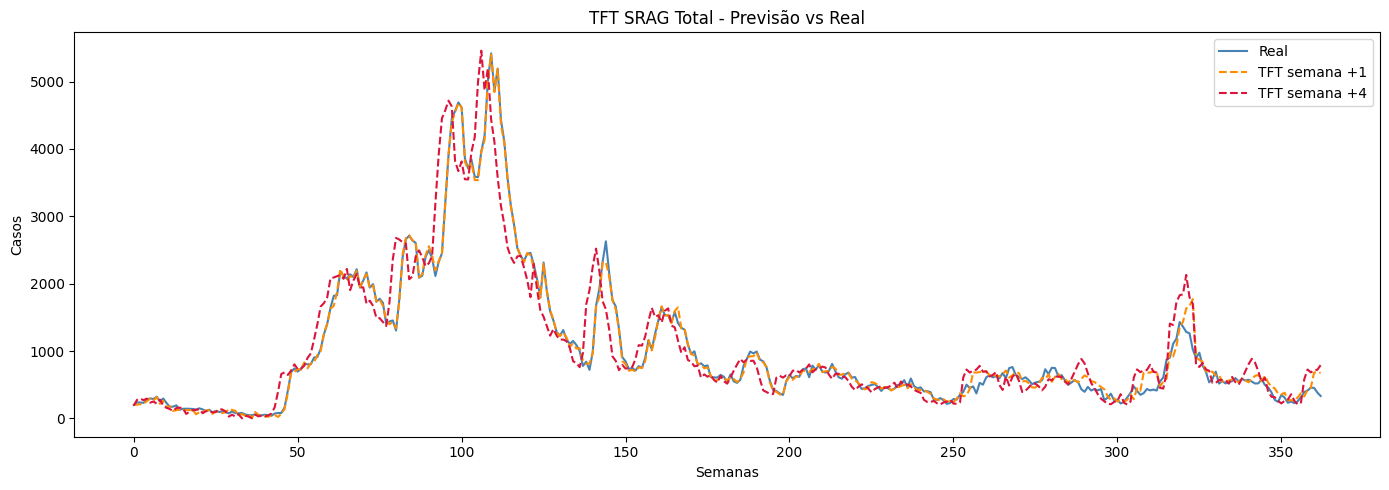

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_real[:, 0], label='Real', color='steelblue', linewidth=1.5)
ax.plot(y_pred[:, 0, 3], label='TFT semana +1', color='darkorange', linewidth=1.5, linestyle='--')
ax.plot(y_pred[:, 3, 3], label='TFT semana +4', color='crimson', linewidth=1.5, linestyle='--')

ax.set_title('TFT SRAG Total - Previsão vs Real')
ax.set_xlabel('Semanas')
ax.set_ylabel('Casos')
ax.legend()
plt.tight_layout()
plt.savefig('/home/valentim/divea/outputs/tft_srag_predicao.png', dpi=150)
plt.show()